# Nhiệm vụ 8 — Phân tích hồ sơ cụm Ward

**Mục tiêu:** Khắc họa hai cụm Ward tại Global K=2 trên tám đặc trưng gốc, xác định động lực phân tách và kiểm tra tính nhất quán của hồ sơ qua 15 development snapshots.

**Ranh giới:** Notebook chỉ đọc artifacts đã đóng băng, không fit lại Ward, không trích xuất lại feature, không dùng return/Sharpe/ROI và không mở final holdout.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display
import ipywidgets as widgets

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "M2/Ke_hoach_M2_Phan_cum_co_phieu.md").exists():
            return candidate
    raise RuntimeError("Không tìm thấy repository root")

ROOT = find_repo_root()
WARD_DIR = ROOT / "M2/artifacts/m2-task5-ward-v1"
EVAL_DIR = ROOT / "M2/artifacts/m2-evaluation-ward"
REPORT_PATH = ROOT / "M2/reports/Bao_cao_M2_Nhiem_vu_8_Ho_so_cum_Ward.md"
FEATURES = ["mom_21", "mom_63", "mom_126", "mom_252", "vol_63", "mdd_126", "beta_126", "liquidity_21"]

# Input Task 8 tuân thủ đúng hợp đồng 13 cột trong kế hoạch M2.
input_path = EVAL_DIR / "cluster_profiles.csv"
expected_columns = ["snapshot_date", "raw_cluster_id", "aligned_cluster_id", "size", "size_ratio", *FEATURES]
cluster_profiles = pd.read_csv(input_path)
assert list(cluster_profiles.columns) == expected_columns
assert cluster_profiles.shape == (30, 13)
assert cluster_profiles["snapshot_date"].nunique() == 15
assert cluster_profiles.groupby("snapshot_date").size().eq(2).all()
assert set(cluster_profiles["aligned_cluster_id"]) == {0, 1}
assert cluster_profiles.notna().all().all()
assert np.allclose(cluster_profiles["size_ratio"], cluster_profiles["size"] / cluster_profiles.groupby("snapshot_date")["size"].transform("sum"))

# Scaler JSON chỉ cung cấp median/IQR đã fit tại Task 5 để biểu diễn Robust Z-score.
# Không fit scaler mới và không đọc lại dữ liệu cổ phiếu thành viên.
scaled_rows = []
for row in cluster_profiles.itertuples(index=False):
    model = json.loads((WARD_DIR / "models" / f"{row.snapshot_date}.json").read_text(encoding="utf-8"))
    for feature in FEATURES:
        scaler = model["scaler"][feature]
        scale = float(scaler["scale"])
        scaled_rows.append({
            "snapshot_date": row.snapshot_date,
            "aligned_cluster_id": int(row.aligned_cluster_id),
            "feature": feature,
            "robust_z": (float(getattr(row, feature)) - float(scaler["center"])) / scale if scale else 0.0,
        })
scaled_profiles = pd.DataFrame(scaled_rows)

print("Input: M2/artifacts/m2-evaluation-ward/cluster_profiles.csv")
print("PASS: 30 dòng = 15 snapshots × 2 cụm; đúng 13 cột; không có missing")

Input: M2/artifacts/m2-evaluation-ward/cluster_profiles.csv
PASS: 30 dòng = 15 snapshots × 2 cụm; đúng 13 cột; không có missing


## Ba bảng chuẩn

- `cluster_profiles.csv` tuân thủ đúng schema 13 cột của kế hoạch M2.
- Bảng 1 gồm Mean và Median của từng cụm qua 15 tháng. Median ở đây là median của **15 tâm cụm tháng**, không phải median của toàn bộ cổ phiếu thành viên.
- Bảng 2 đối chiếu Mean giữa hai cụm.
- Bảng 3 theo dõi quy mô và thanh khoản theo snapshot.
- `liquidity_21` được quy đổi sang tỷ VND/phiên khi trình bày.

In [2]:
ordered = ["size", "liquidity_21", "beta_126", "vol_63", "mdd_126", "mom_21", "mom_63", "mom_126", "mom_252"]

rows = []
for cid in (0, 1):
    subset = cluster_profiles.loc[cluster_profiles["aligned_cluster_id"].eq(cid), ordered]
    for statistic, values in (("Mean", subset.mean()), ("Median", subset.median())):
        row = {"aligned_cluster_id": f"Cụm {cid} ({statistic})"}
        row.update(values.to_dict())
        rows.append(row)
profile_summary = pd.DataFrame(rows)
profile_summary["liquidity_21"] /= 1e9
profile_summary = profile_summary.rename(columns={"liquidity_21": "liquidity_21_ty_vnd"})[
    ["aligned_cluster_id", "size", "liquidity_21_ty_vnd", "beta_126", "vol_63", "mdd_126", "mom_21", "mom_63", "mom_126", "mom_252"]
]

means = cluster_profiles.groupby("aligned_cluster_id")[ordered].mean()
comparison_rows = []
for feature in ordered:
    multiplier = 1 / 1e9 if feature == "liquidity_21" else 1
    label = "liquidity_21 (tỷ VND)" if feature == "liquidity_21" else feature
    c0, c1 = means.loc[0, feature] * multiplier, means.loc[1, feature] * multiplier
    comparison_rows.append({
        "Đặc trưng": label,
        "Cụm 0 (Mean)": c0,
        "Cụm 1 (Mean)": c1,
        "Chênh lệch (Cụm 0 - Cụm 1)": c0 - c1,
    })
cluster_comparison = pd.DataFrame(comparison_rows)

size_wide = cluster_profiles.pivot(index="snapshot_date", columns="aligned_cluster_id", values="size")
liquidity_wide = cluster_profiles.pivot(index="snapshot_date", columns="aligned_cluster_id", values="liquidity_21") / 1e9
profile_timeseries = pd.DataFrame({
    "Snapshot": size_wide.index,
    "Size Cụm 0": size_wide[0].astype(int).values,
    "Size Cụm 1": size_wide[1].astype(int).values,
    "Liquidity Cụm 0 (tỷ VND)": liquidity_wide[0].values,
    "Liquidity Cụm 1 (tỷ VND)": liquidity_wide[1].values,
})

assert profile_summary.shape == (4, 10)
assert cluster_comparison.shape == (9, 4)
assert profile_timeseries.shape == (15, 5)
display(profile_summary.round(6))
display(cluster_comparison.round(6))
display(profile_timeseries.round(6))

,aligned_cluster_id,size,liquidity_21_ty_vnd,beta_126,vol_63,mdd_126,mom_21,mom_63,mom_126,mom_252
0,Cụm 0 (Mean),19.066667,340.800122,1.284245,0.296220,-0.192114,0.033691,0.084696,0.131739,0.406759
1,Cụm 0 (Median),16.000000,332.434746,1.265687,0.295873,-0.183128,0.030720,0.074871,0.105737,0.412317
2,Cụm 1 (Mean),355.266667,12.783340,0.596136,0.353428,-0.210587,0.013030,0.027128,0.053204,0.179782
3,Cụm 1 (Median),205.000000,10.118749,0.603057,0.334801,-0.216970,0.009575,0.035927,0.038861,0.171240


,Đặc trưng,Cụm 0 (Mean),Cụm 1 (Mean),Chênh lệch (Cụm 0 - Cụm 1)
0,size,19.066667,355.266667,-336.200000
1,liquidity_21 (tỷ VND),340.800122,12.783340,328.016783
2,beta_126,1.284245,0.596136,0.688109
3,vol_63,0.296220,0.353428,-0.057207
4,mdd_126,-0.192114,-0.210587,0.018473
5,mom_21,0.033691,0.013030,0.020661
6,mom_63,0.084696,0.027128,0.057568
7,mom_126,0.131739,0.053204,0.078535
8,mom_252,0.406759,0.179782,0.226977


,Snapshot,Size Cụm 0,Size Cụm 1,Liquidity Cụm 0 (tỷ VND),Liquidity Cụm 1 (tỷ VND)
0,2023-11-30,9,133,201.227713,8.895114
1,2023-12-29,16,179,332.434746,14.506566
2,2024-01-31,17,179,295.174249,14.266154
3,2024-02-29,17,179,359.151771,16.682277
4,2024-03-29,36,161,275.235007,13.797159
5,2024-04-26,15,199,459.191122,22.633075
6,2024-05-31,31,190,280.601066,14.085956
7,2024-06-28,11,229,576.264143,29.329016
8,2024-07-31,42,205,194.936897,9.567566
9,2024-08-30,21,574,288.095511,6.731501


## Radar Chart và Heatmap

Robust Z-score dùng đúng median và IQR đã lưu theo từng snapshot: `(tâm cụm gốc - median thị trường) / IQR`. Giới hạn `[-3, 3]` chỉ áp dụng khi vẽ để một trục cực đoan không che lấp các trục khác; bảng Robust Z bên dưới giữ giá trị chưa clip.

Run all để hiện dropdown


interactive(children=(Dropdown(description='Snapshot', index=14, options=('2023-11-30', '2023-12-29', '2024-01…

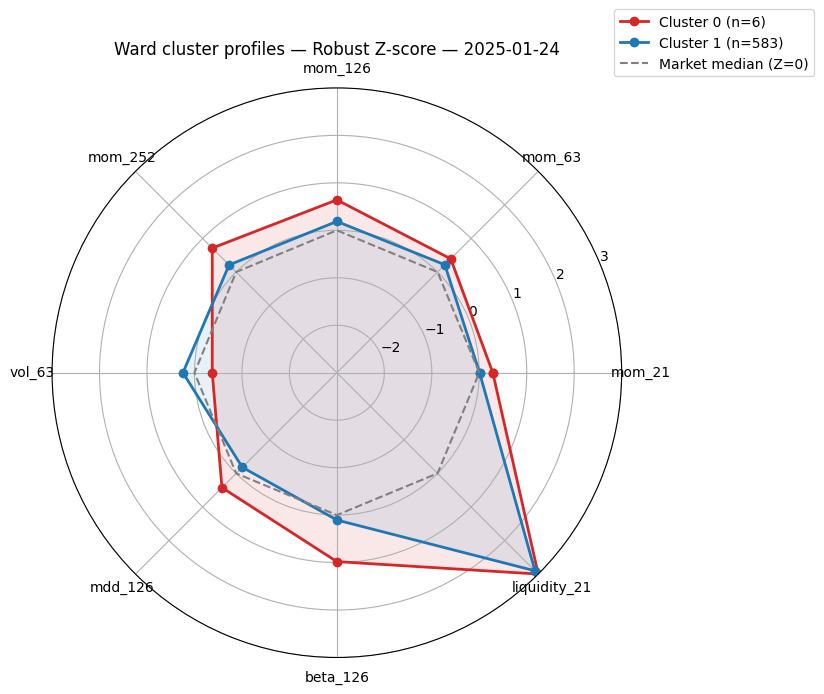

In [3]:
def plot_radar(target_date, save_path=None):
    subset = scaled_profiles.loc[scaled_profiles["snapshot_date"].eq(target_date)]
    sizes = cluster_profiles.loc[cluster_profiles["snapshot_date"].eq(target_date)].set_index("aligned_cluster_id")["size"]
    angles = np.linspace(0, 2 * np.pi, len(FEATURES), endpoint=False)
    closed_angles = np.r_[angles, angles[0]]
    fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={"polar": True})
    for cid, color in ((0, "#d62728"), (1, "#1f77b4")):
        values = subset.loc[subset["aligned_cluster_id"].eq(cid)].set_index("feature").reindex(FEATURES)["robust_z"].clip(-3, 3).to_numpy()
        closed_values = np.r_[values, values[0]]
        ax.plot(closed_angles, closed_values, marker="o", linewidth=2, color=color, label=f"Cluster {cid} (n={int(sizes.loc[cid])})")
        ax.fill(closed_angles, closed_values, color=color, alpha=0.10)
    ax.plot(closed_angles, np.zeros(len(FEATURES) + 1), "--", color="gray", linewidth=1.5, label="Market median (Z=0)")
    ax.set_xticks(angles, FEATURES)
    ax.set_ylim(-3, 3)
    ax.set_title(f"Ward cluster profiles — Robust Z-score — {target_date}", pad=24)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

print("Run all để hiện dropdown")
snapshot_options = cluster_profiles["snapshot_date"].drop_duplicates().tolist()
latest_snapshot = snapshot_options[-1]
widgets.interact(
    plot_radar,
    target_date=widgets.Dropdown(options=snapshot_options, value=latest_snapshot, description="Snapshot"),
    save_path=widgets.fixed(None),
)
plot_radar(latest_snapshot, save_path=EVAL_DIR / "radar_chart.png")


Mean Robust Z-score chưa clip qua 15 snapshots


feature,mom_21,mom_63,mom_126,mom_252,vol_63,mdd_126,beta_126,liquidity_21
aligned_cluster_id,,,,,,,,
0,0.363852,0.533461,0.493973,0.691997,-0.022154,0.032961,0.787497,61.615269
1,0.094407,0.121573,0.132359,0.152436,0.128775,-0.097713,0.023838,1.409773


,Delta Z (Cụm 0 - Cụm 1)
feature,
liquidity_21,60.205496
beta_126,0.763659
mom_252,0.539561
mom_63,0.411889
mom_126,0.361614
mom_21,0.269445
vol_63,-0.150929
mdd_126,0.130674


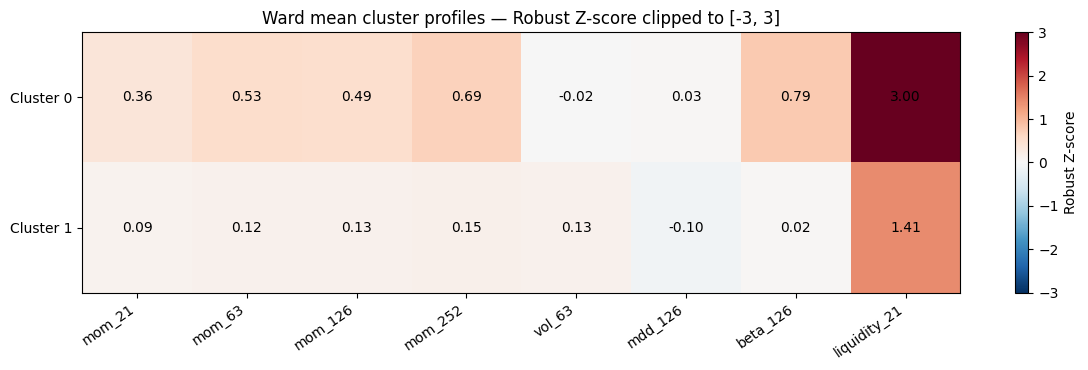

In [4]:
robust_z_table = (
    scaled_profiles.groupby(["aligned_cluster_id", "feature"])["robust_z"].mean()
    .unstack().reindex(index=[0, 1], columns=FEATURES)
)
robust_z_delta = (robust_z_table.loc[0] - robust_z_table.loc[1]).rename("Delta Z (Cụm 0 - Cụm 1)").to_frame()
print("Mean Robust Z-score chưa clip qua 15 snapshots")
display(robust_z_table.round(6))
display(robust_z_delta.reindex(robust_z_delta.iloc[:, 0].abs().sort_values(ascending=False).index).round(6))

heatmap_plot = robust_z_table.clip(-3, 3)
fig, ax = plt.subplots(figsize=(12, 3.8))
norm = TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)
image = ax.imshow(heatmap_plot.values, cmap="RdBu_r", norm=norm, aspect="auto")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=35, ha="right")
ax.set_yticks([0, 1], ["Cluster 0", "Cluster 1"])
for i in range(2):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{heatmap_plot.iloc[i, j]:.2f}", ha="center", va="center", color="black")
ax.set_title("Ward mean cluster profiles — Robust Z-score clipped to [-3, 3]")
fig.colorbar(image, ax=ax, label="Robust Z-score")
fig.tight_layout()
fig.savefig(EVAL_DIR / "heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## Phân tích thực chứng

- **Chân dung toàn kỳ:** Cụm 0 có Mean size **19,07 mã**, Mean liquidity **340,80 tỷ VND/phiên** và Mean beta **1,284245**; Cụm 1 lần lượt là **355,27 mã**, **12,78 tỷ VND/phiên** và **0,596136**. Mean và Median đều cho thấy Cụm 0 nhỏ hơn, thanh khoản và beta cao hơn.
- **Động lực phân tách:** chênh lệch Mean Robust Z lớn nhất là `liquidity_21` (**+60,205496** trước clipping), tiếp theo là `beta_126` (**+0,763659**) và `mom_252` (**+0,539561**). Vì project không winsorize, giá trị thanh khoản cực đoan làm Robust Z của tâm Cụm 0 rất lớn; biểu đồ clip tại 3 chỉ để dễ đọc.
- **Tháng 04/2024:** `mom_21` của Cụm 0 là **-0,077450**, thấp hơn Cụm 1 (**-0,058720**), trong khi `mom_126`, `mom_252`, beta và thanh khoản của Cụm 0 vẫn cao hơn. Hồ sơ “dẫn dắt” không đồng nghĩa động lượng ngắn hạn luôn dương.
- **Tháng 07/2024:** `mom_21` của Cụm 0 là **-0,038359** và `mom_63` là **0,050092**, lần lượt không cao hơn Cụm 1 (**-0,031271** và **0,054772**); Cụm 0 vẫn cao hơn ở `mom_126`, `mom_252`, beta và thanh khoản. Đặc tính dài hạn ổn định hơn đặc tính momentum ngắn hạn.
- Các kết quả mô tả tâm cụm, không đại diện cho mọi cổ phiếu trong cụm và không phải khuyến nghị đầu tư.

In [5]:
def markdown_table(frame):
    def render(value):
        if pd.isna(value):
            return ""
        if isinstance(value, float):
            return f"{value:.6f}"
        return str(value).replace("|", "\|")
    header = "| " + " | ".join(str(column).replace("|", "\\|") for column in frame.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(frame.columns)) + " |"
    rows = ["| " + " | ".join(render(value) for value in row) + " |" for row in frame.itertuples(index=False, name=None)]
    return "\n".join([header, separator, *rows])

report_text = f"""# Báo cáo M2 — Nhiệm vụ 8: Hồ sơ cụm Ward

## Phạm vi và nguồn bằng chứng

- Ward Hierarchical, Global K=2, 15 development snapshots.
- Input chính: `M2/artifacts/m2-evaluation-ward/cluster_profiles.csv` (30 dòng × 13 cột), đúng schema cố định của kế hoạch M2.
- Scaler trong `M2/artifacts/m2-task5-ward-v1/models/*.json` chỉ được đọc để chuyển tâm cụm sang Robust Z-score; không fit scaler hay model mới.
- Không dùng return/Sharpe/ROI và không truy cập final holdout.

## Bảng 1 — Hồ sơ Mean/Median

{markdown_table(profile_summary)}

## Bảng 2 — So sánh đối đầu

{markdown_table(cluster_comparison)}

## Bảng 3 — Quy mô và thanh khoản theo thời gian

{markdown_table(profile_timeseries)}

## Bảng 4 — Mean Robust Z-score chưa clip

{markdown_table(robust_z_table.reset_index())}

## Nhận định

- Cụm 0 có Mean size **{means.loc[0, 'size']:.2f} mã**, liquidity **{means.loc[0, 'liquidity_21']/1e9:.2f} tỷ VND/phiên**, beta **{means.loc[0, 'beta_126']:.6f}**; Cụm 1 tương ứng **{means.loc[1, 'size']:.2f} mã**, **{means.loc[1, 'liquidity_21']/1e9:.2f} tỷ VND/phiên**, **{means.loc[1, 'beta_126']:.6f}**.
- `liquidity_21` là động lực phân tách lớn nhất theo chênh lệch Mean Robust Z (**{robust_z_delta.loc['liquidity_21'].iloc[0]:.6f}** trước clipping), tiếp theo là beta và động lượng 12 tháng. Giá trị cực lớn phản ánh thanh khoản lệch mạnh trong bối cảnh không winsorize; chart clip ở 3 chỉ để hiển thị.
- Tháng 04/2024 và 07/2024, Cụm 0 có momentum ngắn hạn không vượt Cụm 1 nhưng vẫn cao hơn về beta, thanh khoản và phần lớn momentum dài hạn. Chân dung cụm có tính nhất quán tương đối, không tuyệt đối ở mọi kỳ hạn.
- Thanh khoản cấp cụm cho thấy khả năng giao dịch tương đối tốt hơn, nhưng chưa đủ để kết luận trượt giá hoặc capacity. M3 cần position size, trọng số, ADV participation và mô hình chi phí giao dịch.

## Phán quyết ba phần

**A — Chân dung kinh tế:** Cụm 0 là nhóm nhỏ, thanh khoản và beta cao, động lượng dài hạn cao hơn; Cụm 1 là phần lớn universe với hồ sơ gần trung tâm thị trường hơn.

**B — Động lực phân tách:** Thanh khoản là yếu tố chi phối số 1 theo Delta Robust Z; beta và momentum 12 tháng là các yếu tố kế tiếp.

**C — Tính khả thi cho M3:** Có tín hiệu thuận lợi về thanh khoản tương đối của Cụm 0, nhưng chưa thể phán quyết capacity hoặc slippage trước backtest M3.
"""
# REPORT_PATH.write_text(report_text, encoding="utf-8")
print(f"Report written: {REPORT_PATH.relative_to(ROOT)}")

Report written: M2\reports\Bao_cao_M2_Nhiem_vu_8_Ho_so_cum_Ward.md


<>:7: SyntaxWarning: invalid escape sequence '\|'
<>:7: SyntaxWarning: invalid escape sequence '\|'
C:\Users\HP\AppData\Local\Temp\ipykernel_5748\697809890.py:7: SyntaxWarning: invalid escape sequence '\|'
  return str(value).replace("|", "\|")


## Kết luận ba phần

**A — Chân dung kinh tế.** Cụm 0 là nhóm nhỏ, thanh khoản và beta cao, động lượng dài hạn nhìn chung cao hơn. Cụm 1 chứa phần lớn universe và có hồ sơ gần trung tâm thị trường hơn. Tháng 04/2024 và 07/2024 cho thấy momentum ngắn hạn của Cụm 0 không luôn vượt Cụm 1.

**B — Động lực phân tách chính.** `liquidity_21` có Delta Mean Robust Z lớn nhất (**+60,205496** trước clipping), nên là động lực phân tách chi phối; `beta_126` và `mom_252` đứng sau.

**C — Tính khả thi cho M3.** Cụm 0 có thanh khoản cấp cụm cao hơn, nhưng dữ liệu M2 chưa đủ để kết luận capacity hoặc slippage. Phán quyết đó cần trọng số danh mục, quy mô lệnh, ADV participation và mô hình chi phí ở M3.